In [1]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"



In [2]:
defaultConfig = {"Budget": 3}
inputConfigs = {
    "(AU)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Overall", "AU"]]},
    "(Hal, Carla)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Hal", "AU"], ["Carla", "AU"]]},
    "(Hal)^0, (Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0]], "Considerations": [["Carla", "Carla"], ["Hal", "Hal"]]},
    "(Hal)^0, (Carla)^0, (Hal,Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0], ["AU", "Utility", 0]], "Considerations": [["Carla",["AU", "Carla"]], ["Hal", ["AU", "Hal"]]]},
    #"(HalLife)^0, (CaraLife)^0": {
    #    "Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0]],
    #    "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"]]
    #}
}
Config_repetitions=1
Environment_repetitions = 10
configs = []
for i in range(3,12):
    for old_name, c in inputConfigs.items():
        c = deepcopy(defaultConfig) | c
        c["Name"] = f"H{i}_{old_name}"
        c["Horizon"] = i
        configs.append(c)
    
Config_repetitions = 1
Environment_repetitions = 10

In [3]:
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../")
er.buildEnvironments(configRepetitions=1)
er.run(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)
er.saveResults()

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-07-12_20:00:42/mdps/H3_(AU)_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-07-12_20:00:42/mdps/H3_(Hal, Carla)_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-07-12_20:00:42/mdps/H3_(Hal)^0, (Carla)^0_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/Mor

In [4]:
data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            e = {
                "Config_name": c["Name"],
                "Env_rep" : env_rep,
                "Horizon": json_data["Horizon"],
                "Heuristic": json_data["Duration_Heuristic"],
                "Plan": json_data["Duration_Plan"],
                "Solution Extraction": json_data["Duration_Sols"],
                "MEHR": json_data["Duration_MEHR"],
                "Total" : json_data["Duration_Total"]
            }
            data.append(e)
time_cols = ["Heuristic", "Plan", "Solution Extraction", "MEHR", "Total"]
df = pd.DataFrame(data)
df["Config_name"] = df["Config_name"].str.split("_").str[-1]

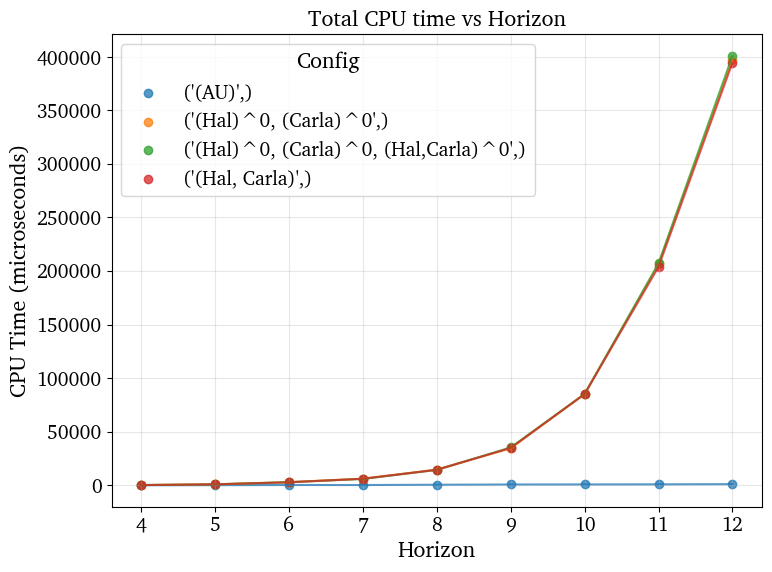

In [5]:

df_a = df[df['Config_name']!="(HalLife)^0, (CaraLife)^0"].copy()
df_a = (
    df_a
    .groupby(["Config_name", "Horizon"], as_index=False)["Total"]
    .mean()
    .sort_values(["Config_name", "Horizon"])
)

fig, ax = plt.subplots(figsize=(8, 6))
for c, g in df_a.groupby(['Config_name'], sort=False):
    x = g["Horizon"].mean()
    ax.scatter(g["Horizon"],
            g['Total'],
            alpha=0.75,
            label=c)

    ax.plot(g["Horizon"],
            g['Total'],
            alpha=0.75)

#plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title("Total CPU time vs Horizon")
plt.xlabel("Horizon")
plt.ylabel("CPU Time (microseconds)")

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.tight_layout() 
plt.show()  # Show the plot



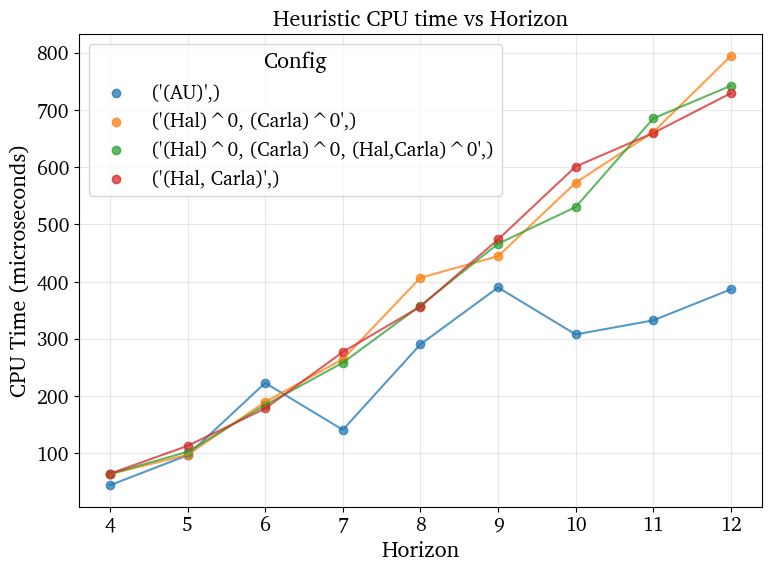

In [6]:
df_a = df[df['Config_name']!="(HalLife)^0, (CaraLife)^0"].copy()
time_metric = "Heuristic"
df_a = (
    df_a
    .groupby(["Config_name", "Horizon"], as_index=False)[time_metric]
    .mean()
    .sort_values(["Config_name", "Horizon"])
)

fig, ax = plt.subplots(figsize=(8, 6))
for c, g in df_a.groupby(['Config_name'], sort=False):
    x = g["Horizon"].mean()
    ax.scatter(g["Horizon"],
            g[time_metric],
            alpha=0.75,
            label=c)

    ax.plot(g["Horizon"],
            g[time_metric],
            alpha=0.75)

#plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title(f"{time_metric} CPU time vs Horizon")
plt.xlabel("Horizon")
plt.ylabel("CPU Time (microseconds)")

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.tight_layout() 
plt.show()  # Show the plot



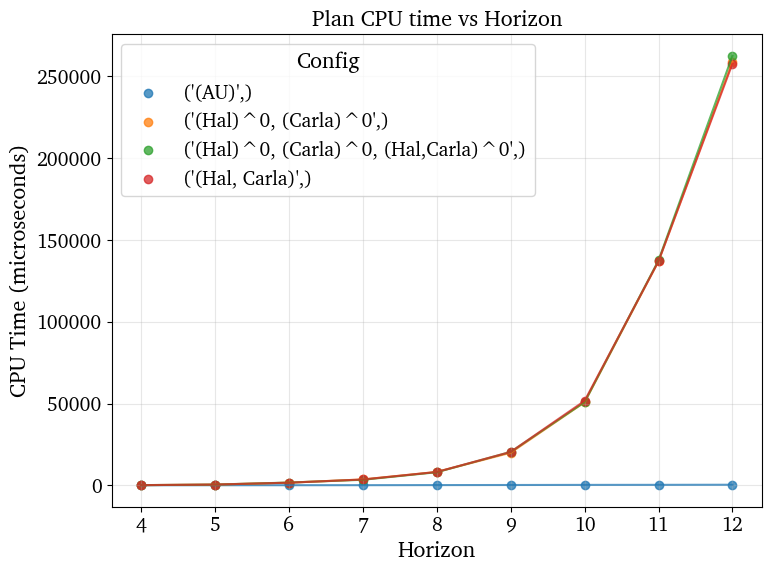

In [7]:
df_a = df[df['Config_name']!="(HalLife)^0, (CaraLife)^0"].copy()
time_metric = "Plan"
df_a = (
    df_a
    .groupby(["Config_name", "Horizon"], as_index=False)[time_metric]
    .mean()
    .sort_values(["Config_name", "Horizon"])
)

fig, ax = plt.subplots(figsize=(8, 6))
for c, g in df_a.groupby(['Config_name'], sort=False):
    x = g["Horizon"].mean()
    ax.scatter(g["Horizon"],
            g[time_metric],
            alpha=0.75,
            label=c)

    ax.plot(g["Horizon"],
            g[time_metric],
            alpha=0.75)

#plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title(f"{time_metric} CPU time vs Horizon")
plt.xlabel("Horizon")
plt.ylabel("CPU Time (microseconds)")

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.tight_layout() 
plt.show()  # Show the plot

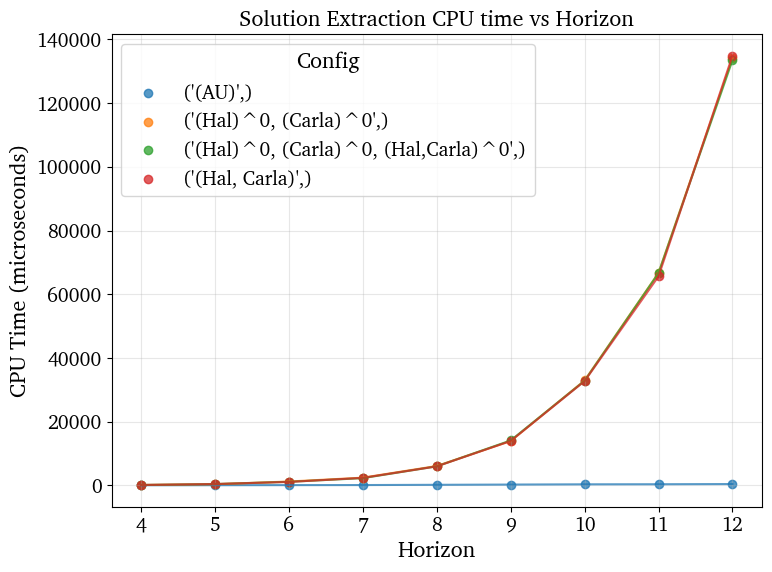

In [8]:
df_a = df[df['Config_name']!="(HalLife)^0, (CaraLife)^0"].copy()
time_metric = "Solution Extraction"
df_a = (
    df_a
    .groupby(["Config_name", "Horizon"], as_index=False)[time_metric]
    .mean()
    .sort_values(["Config_name", "Horizon"])
)

fig, ax = plt.subplots(figsize=(8, 6))
for c, g in df_a.groupby(['Config_name'], sort=False):
    x = g["Horizon"].mean()
    ax.scatter(g["Horizon"],
            g[time_metric],
            alpha=0.75,
            label=c)

    ax.plot(g["Horizon"],
            g[time_metric],
            alpha=0.75)

#plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title(f"{time_metric} CPU time vs Horizon")
plt.xlabel("Horizon")
plt.ylabel("CPU Time (microseconds)")

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.tight_layout() 
plt.show()  # Show the plot

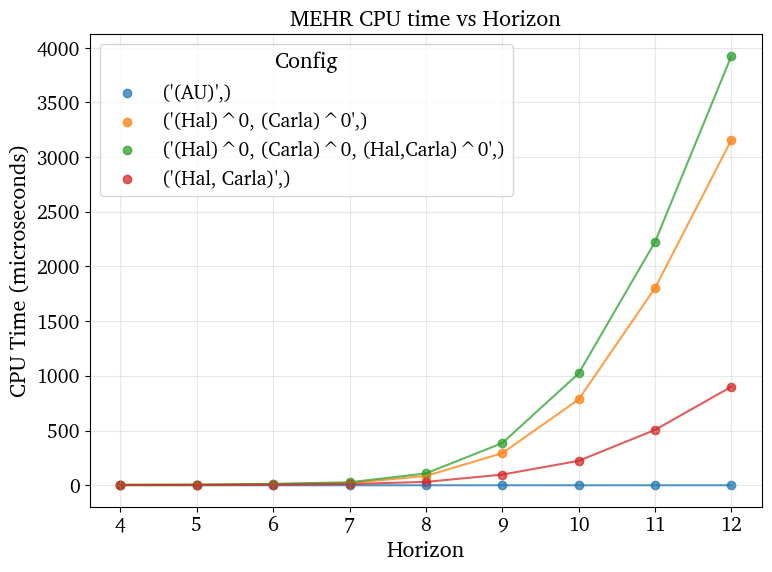

In [9]:
df_a = df[df['Config_name']!="(HalLife)^0, (CaraLife)^0"].copy()
df_a = (
    df_a
    .groupby(["Config_name", "Horizon"], as_index=False)["MEHR"]
    .mean()
    .sort_values(["Config_name", "Horizon"])
)

fig, ax = plt.subplots(figsize=(8, 6))
for c, g in df_a.groupby(['Config_name'], sort=False):
    x = g["Horizon"].mean()
    ax.scatter(g["Horizon"],
            g['MEHR'],
            alpha=0.75,
            label=c)

    ax.plot(g["Horizon"],
            g['MEHR'],
            alpha=0.75)

#plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title("MEHR CPU time vs Horizon")
plt.xlabel("Horizon")
plt.ylabel("CPU Time (microseconds)")

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.tight_layout() 
plt.show()  # Show the plot



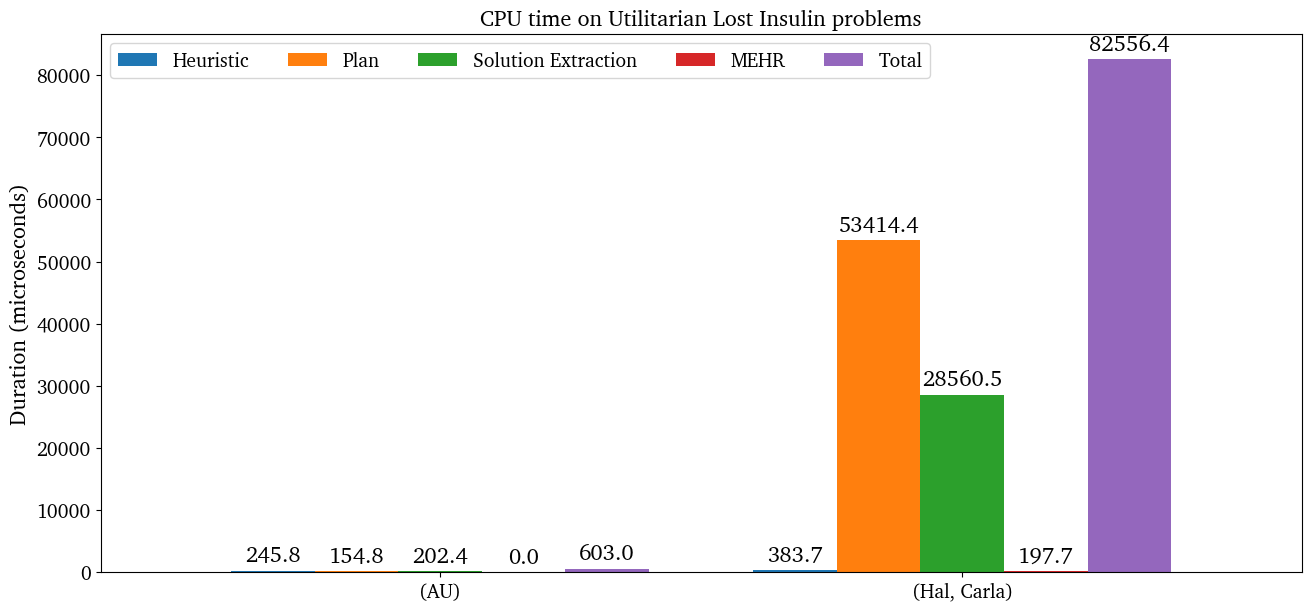

In [10]:
import re
time_categories = ['Heuristic', 'Plan', 'Solution Extraction', 'MEHR', 'Total']

df_b = df[df['Config_name'].isin(["(AU)", "(Hal, Carla)"])]

averages = df_b.groupby('Config_name', sort=False)[time_categories].mean()


fig, ax = plt.subplots(layout='constrained', figsize=(13, 6))

averages.plot.bar(ax=ax, width=0.8, rot=0)

for container in ax.containers:
    formatted_label = re.sub(r"\^(\d)", r"$^{\1}$", str(container))
    ax.bar_label(container, padding=3, fmt='%.1f')
    
ax.set_ylabel('Duration (microseconds)')
ax.set_xlabel('')
ax.set_title('CPU time on Utilitarian Lost Insulin problems')

ax.legend(loc='upper left', ncols=5)
ax.set_ylim(0, averages['Total'].max() * 1.05)

plt.savefig(f"{er.figuresFolder}/TimeGraph.png", dpi=300)
plt.show()

In [ ]:
config_name = "(Hal)^0, (Carla)^0"

time_categories = [
    "Heuristic",
    "Plan",
    "Solution Extraction",
    "MEHR"
]

df_a = df[df["Config_name"] == config_name].copy()

# Percentage of total time taken by each category for each run
percentage_columns = []

for category in time_categories:
    percentage_column = f"{category}_percent"

    df_a[percentage_column] = (
        df_a[category]
        .div(df_a["Total"])
        .mul(100)
    )

    percentage_columns.append(percentage_column)

# Mean percentage at each horizon
mean_percentages = (
    df_a
    .groupby("Horizon", as_index=False)[percentage_columns]
    .mean()
    .sort_values("Horizon")
)

fig, ax = plt.subplots(figsize=(8, 6))

for category, percentage_column in zip(
    time_categories,
    percentage_columns
):
    ax.scatter(
        mean_percentages["Horizon"],
        mean_percentages[percentage_column],
        alpha=0.75
    )

    ax.plot(
        mean_percentages["Horizon"],
        mean_percentages[percentage_column],
        alpha=0.75,
        label=category
    )

ax.set_title(
    f"Mean CPU time distribution vs Horizon\n{config_name}"
)
ax.set_xlabel("Horizon")
ax.set_ylabel("Mean percentage of total CPU time")

ax.set_ylim(0, 100)
ax.set_xticks(sorted(mean_percentages["Horizon"].unique()))

ax.grid(True, alpha=0.3)
ax.legend(title="Time category", loc="best")

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

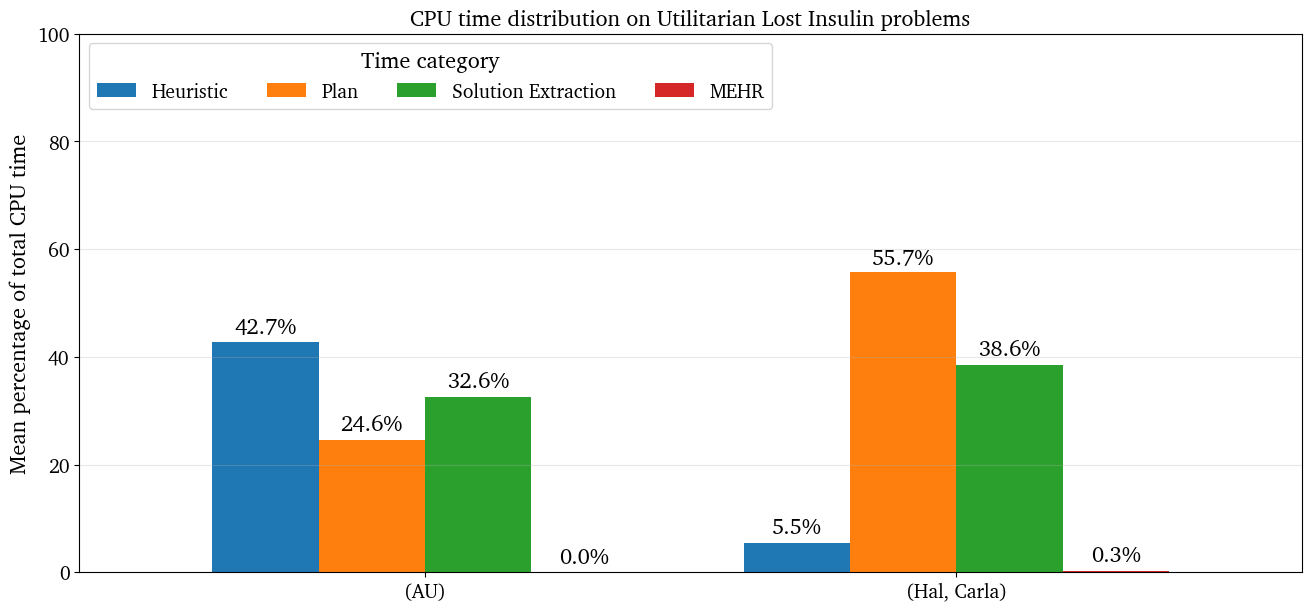

In [12]:
no_total_time_categories = [
    "Heuristic",
    "Plan",
    "Solution Extraction",
    "MEHR"
]

df_df_ba = df[df['Config_name']!="(HalLife)^0, (CaraLife)^0"].copy()

# Convert each time category to a percentage of Total for that run
df_b[no_total_time_categories] = (df_b[no_total_time_categories].div(df_b["Total"], axis=0).mul(100))

# Mean percentage for each configuration
average_percentages = (
    df_b
    .groupby("Config_name", sort=False)[no_total_time_categories]
    .mean()
)

fig, ax = plt.subplots(layout="constrained", figsize=(13, 6))

average_percentages.plot.bar(
    ax=ax,
    width=0.8,
    rot=0
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fmt="%.1f%%"
    )

ax.set_ylabel("Mean percentage of total CPU time")
ax.set_xlabel("")
ax.set_title("CPU time distribution on Utilitarian Lost Insulin problems")

ax.legend(
    title="Time category",
    loc="upper left",
    ncols=4
)

ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

plt.savefig(
    f"{er.figuresFolder}/TimePercentageGraph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            data.append([json_data["Horizon"], env_rep, 
                            len(json_data["Solutions"]),
                            json_data["Backups"],
                            json_data["Total_Attacks"],
                            json_data["Total_states"]])
            
props_cols = ["Total Solutions", "Total Backups", "Total Attacks", "Total States"]
cols = ["Horizon", "Env_rep"] + props_cols
df = pd.DataFrame(data, columns=cols)

: 

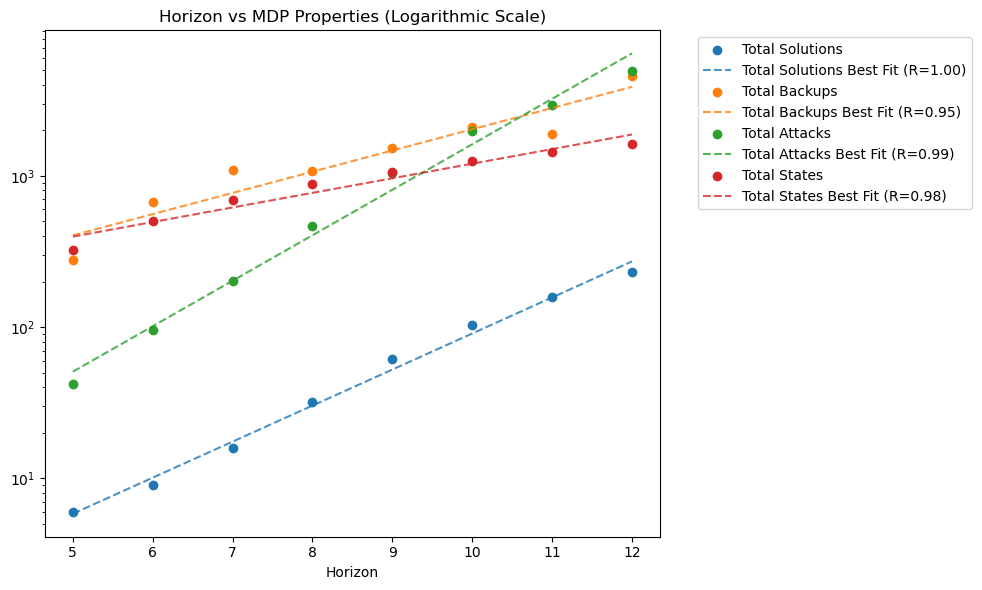

: 

In [ ]:
averages_props = df.groupby('Horizon')[props_cols].mean().reset_index()

plt.figure(figsize=(10, 6))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, column in enumerate(props_cols):
    current_color = colors[i % len(colors)]
    
    plt.scatter(average_durations['Horizon'], averages_props[column], color=current_color, label=column)

    # Calculate best fit line
    x = averages_props['Horizon']
    y = averages_props[column]
    slope, intercept, r_value, _, _ = linregress(x, np.log10(y))  # Fit line in log scale
    best_fit_line = 10 ** (slope * x + intercept)  # Transform back to original scale    
    plt.plot(x, best_fit_line, linestyle='--', color=current_color, alpha=0.8, label=f'{column} Best Fit (R={r_value:.2f})')

plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title("Horizon vs MDP Properties (Logarithmic Scale)")
plt.xlabel("Horizon")
plt.xticks(ticks=np.arange(min(averages_props['Horizon']), max(averages_props['Horizon']) + 1, 1))

# Optional: move legend outside if it gets too cluttered with double labels
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

plt.tight_layout() # Ensures the legend isn't cut off if moved outside
plt.savefig(er.outputFolder + "propsVHorizon_LOG_SCALE.png")  # Save the plot
plt.show()  # Show the plot

In [ ]:
cols = ["Config_name", 'Hal_Utility', 'Carla_Utility', "Min_non_accept", "Num_of_min_non_accept", "Num_of_sols", "Total_time"]
df = pd.DataFrame(er.data, columns=["Horizon", "Env_rep", 'Hal', 'Carla'])

df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df.head(100)



,Horizon,Env_rep,Hal,Carla
0,5,0,-68.9674,0
1,5,1,-68.9674,0
2,5,2,-68.9674,0
3,5,3,-68.9674,0
4,5,4,-68.9674,0
...,...,...,...,...
95,11,5,-49.2727,-15.4549
96,11,6,-49.2727,-15.4549
97,11,7,-49.2727,-15.4549
98,11,8,-49.2727,-15.4549


: 

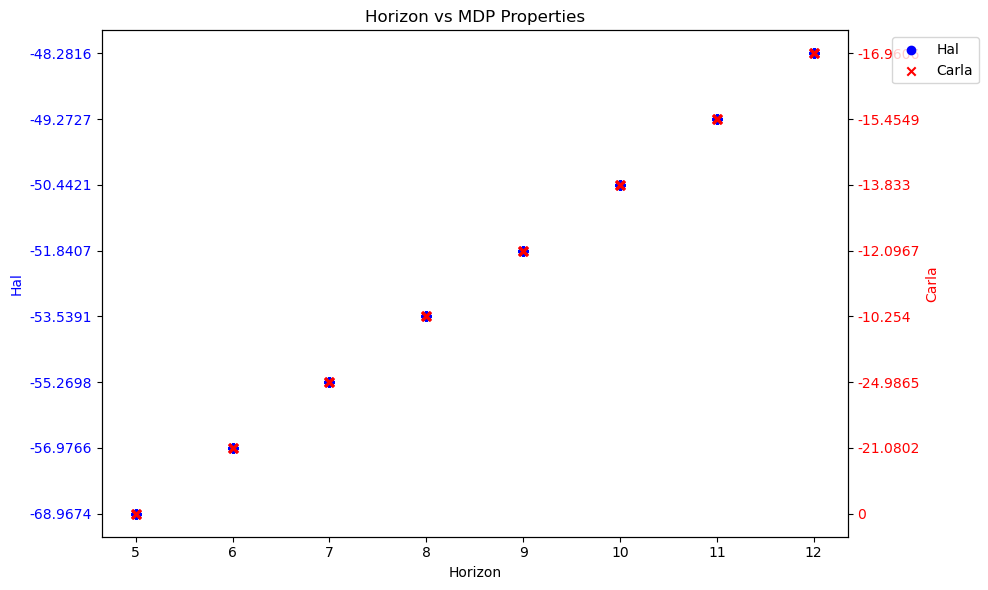

: 

In [ ]:
# Create the figure and the primary axis (for Hal)
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Y-Axis (Hal) ---
color_hal = 'blue'
ax1.set_xlabel('Horizon')
ax1.set_ylabel('Hal', color=color_hal)
scatter_hal = ax1.scatter(df['Horizon'], df['Hal'], color=color_hal, label='Hal')
ax1.tick_params(axis='y', labelcolor=color_hal)

# Set x-ticks using the primary axis
ax1.set_xticks(np.arange(min(averages_props['Horizon']), max(averages_props['Horizon']) + 1, 1))

# --- Right Y-Axis (Carla) ---
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color_carla = 'red'
ax2.set_ylabel('Carla', color=color_carla)
scatter_carla = ax2.scatter(df['Horizon'], df['Carla'], color=color_carla, label='Carla', marker='x')
ax2.tick_params(axis='y', labelcolor=color_carla)

# --- Title and Legend ---
plt.title("Horizon vs MDP Properties")

# To get a single legend for both axes, we combine the handles and labels
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Formatting and Saving ---
fig.tight_layout() # Ensures the legend isn't cut off
plt.savefig(er.outputFolder + "HalCarla_V_Horizon.png")
plt.show()